In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import numpy as np


In [16]:
data = pd.read_csv("housing.csv", index_col= 0)
data.head()

,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
longitude,,,,,,,,,
-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## EDA

In [5]:
data.shape

(20640, 9)

**20,640 rows** represent the total number of observations/records in the dataset.
**9 columns** represent the different features available for analysis.

In [6]:
data.info()

<class 'pandas.DataFrame'>
Index: 20640 entries, -122.23 to -121.24
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   latitude            20640 non-null  float64
 1   housing_median_age  20640 non-null  float64
 2   total_rooms         20640 non-null  float64
 3   total_bedrooms      20433 non-null  float64
 4   population          20640 non-null  float64
 5   households          20640 non-null  float64
 6   median_income       20640 non-null  float64
 7   median_house_value  20640 non-null  float64
 8   ocean_proximity     20640 non-null  str    
dtypes: float64(8), str(1)
memory usage: 1.6 MB


Most columns have the `float64` data type, meaning they contain numerical values.  
The `ocean_proximity` column has the `object` data type because it contains categorical/text values.

The `total_bedrooms` column contains only **20,433 non-null values**, indicating that some values are missing in this column.

In [7]:
data.isna().sum()

latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

The result shows that most columns have **no missing values**. However, the `total_bedrooms` column contains **207 missing values**.

In [9]:
data.duplicated().sum()

np.int64(0)

The result is **0**, which means there are **no duplicate rows** in the dataset. Therefore, no duplicate records need to be removed during data preprocessing.

In [14]:
data.columns

Index(['latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms',
       'population', 'households', 'median_income', 'median_house_value',
       'ocean_proximity'],
      dtype='str')

Visualization

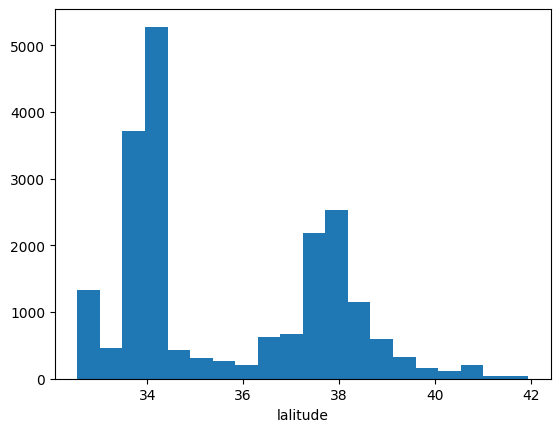

In [41]:
plt.hist(x = data["latitude"], bins = 20)
plt.xlabel("lalitude")
plt.show()

Most housing observations are concentrated around **34° latitude**, with more than **5,000 observations**. Another concentration can be seen around **37–38°**, while fewer observations are found at higher latitude values.

a positive relationship between median income and median house value. 
As median income increases, median house value generally tends to increase. 
A noticeable concentration of values can also be seen around 500,000.

In [55]:
data["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

/var/folders/mm/l4jbgxs16cs2bw920h3dj92h0000gn/T/ipykernel_3390/1027690907.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = data, x = "ocean_proximity",palette = "tab10")


<Axes: xlabel='ocean_proximity', ylabel='count'>

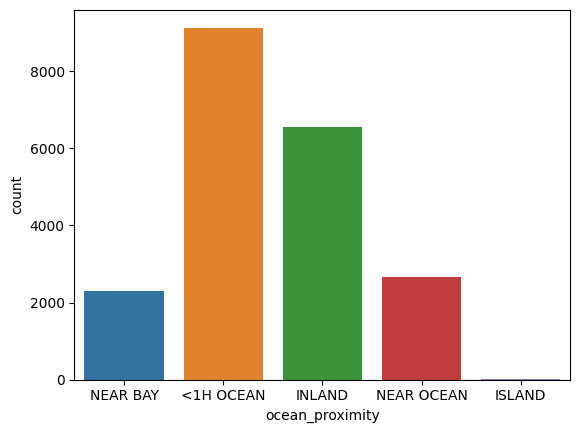

In [54]:
sns.countplot(data = data, x = "ocean_proximity",palette = "tab10")

<1H OCEAN` has the highest number of observations, followed by `INLAND`. `NEAR OCEAN` and `NEAR BAY` have fewer observations, while `ISLAND` has very few only 5 observations compared to the other categories.

Text(0.5, 1.0, 'median_income vs Median House Value')

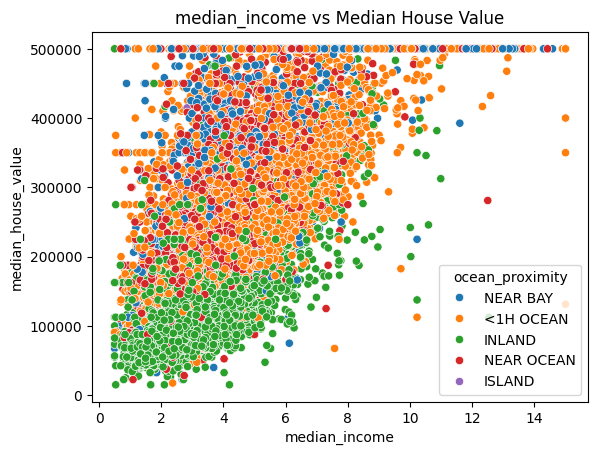

In [87]:
sns.scatterplot(data = data,
                x = "median_income",
                y = "median_house_value",
                hue="ocean_proximity"

               )
plt.title("median_income vs Median House Value")


clear positive relationship between median income and median house value. As median income increases, house value generally tends to increase. The colors also show differences among the ocean proximity categories. A concentration of observations around 500,000 can also be seen.

Text(0.5, 1.0, 'total rooms vs Median House Value')

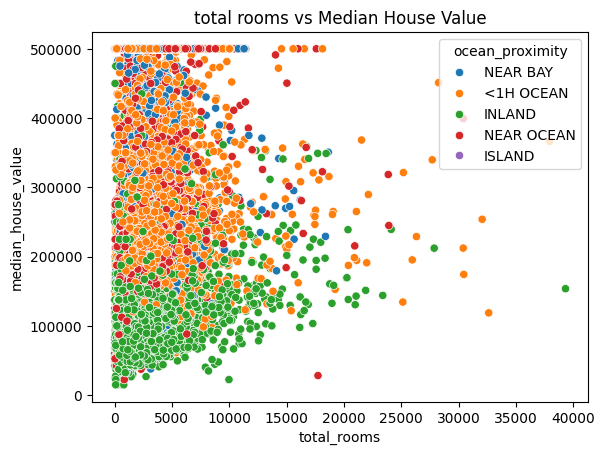

In [88]:
sns.scatterplot(data = data,
                x = "total_rooms",
                y = "median_house_value",
                hue="ocean_proximity"

               )
plt.title("total rooms vs Median House Value")


The scatterplot shows a weak positive relationship between total rooms and median house value. Most observations are concentrated at lower total room values, while some observations have a very large number of rooms. The different colors represent the ocean proximity categories.

Text(0.5, 1.0, 'Latitude vs Median House Value')

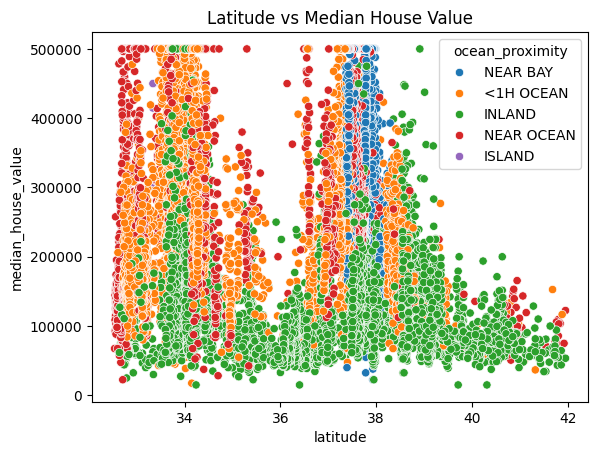

In [89]:
sns.scatterplot(data = data,
                x = "latitude",
                y = "median_house_value",
                hue="ocean_proximity"

               )
plt.title("Latitude vs Median House Value")


weak negative overall relationship between latitude and median house value. House values vary considerably across different latitude values, so latitude alone does not show a strong linear relationship with house value.`m

<Axes: xlabel='population'>

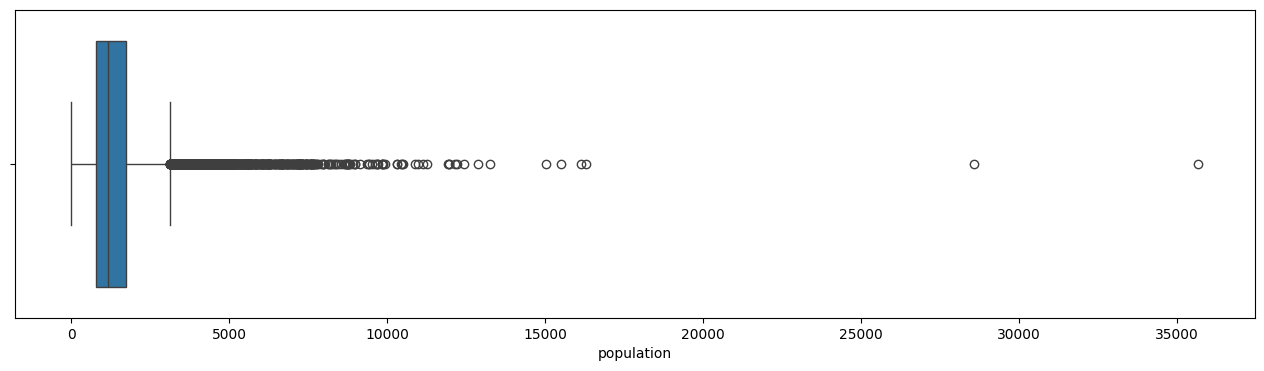

In [93]:
plt.figure(figsize=(16, 4))
sns.boxplot(
    data=data,
    x="population",
    
)


The boxplot shows that the population variable is right-skewed and contains many potential outliers.

In [66]:
correlation = data.select_dtypes(include="number").corr()
correlation["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
latitude             -0.144160
Name: median_house_value, dtype: float64

<Axes: >

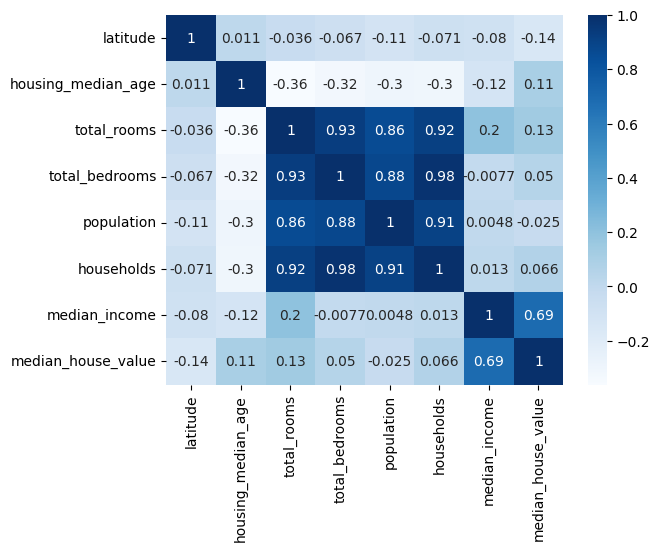

In [80]:
sns.heatmap(
    data = correlation,
    fmt= ".2g",
    annot = True,
    cmap ="Blues"
    
    

)

The correlation heatmap shows the relationships between the numerical variables. Median income has the strongest positive correlation with median house value (0.69). Total rooms, total bedrooms, population, and households also show strong positive correlations with each other. Most other variables have relatively weak linear relationships with median house value.

## data preprocessing 

In [94]:
data["total_bedrooms"].describe()

count    20433.000000
mean       537.870553
std        421.385070
min          1.000000
25%        296.000000
50%        435.000000
75%        647.000000
max       6445.000000
Name: total_bedrooms, dtype: float64

In [99]:
data["total_bedrooms"] =  data["total_bedrooms"].fillna(data.total_bedrooms.median())

In [100]:
data.isna().sum()

latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [101]:
data.head()

,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
longitude,,,,,,,,,
-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [103]:
# encode ocean_proximity -  one hot encoding
data = pd.get_dummies(
    data = data,
    columns= ["ocean_proximity"],
    dtype= int
)


In [26]:
data.head()

,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
longitude,,,,,,,,,,,,,
-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0


In [47]:
# split into input and target
X = data.drop("median_house_value", axis = 1).to_numpy()
y =  data["median_house_value"].to_numpy()

In [48]:
# SCALING X
scaler =  StandardScaler()
X_Scaled =  scaler.fit_transform(X)
X_Scaled


array([[ 1.05254828,  0.98214266, -0.8048191 , ..., -0.01556621,
         2.83074203, -0.38446649],
       [ 1.04318455, -0.60701891,  2.0458901 , ..., -0.01556621,
         2.83074203, -0.38446649],
       [ 1.03850269,  1.85618152, -0.53574589, ..., -0.01556621,
         2.83074203, -0.38446649],
       ...,
       [ 1.77823747, -0.92485123, -0.17499526, ..., -0.01556621,
        -0.35326426, -0.38446649],
       [ 1.77823747, -0.84539315, -0.35559977, ..., -0.01556621,
        -0.35326426, -0.38446649],
       [ 1.75014627, -1.00430931,  0.06840827, ..., -0.01556621,
        -0.35326426, -0.38446649]], shape=(20640, 12))

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X_Scaled, y , test_size= 0.2, random_state=999)

In [51]:
from sklearn.linear_model import LinearRegression

In [52]:
model =  LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [53]:
model.coef_

array([ 7.17488221e+01,  1.48660050e+04, -1.22002619e+04,  2.09998512e+04,
       -4.29073281e+04,  3.96763707e+04,  7.51889356e+04,  9.79073950e+03,
       -2.28241286e+04,  2.81227302e+03,  6.81016158e+03,  1.06822841e+04])

In [64]:
model.intercept_

np.float64(206463.37699699795)

In [65]:
SSE = np.sum(np.power(y_train - model.predict(X_train), 2))
SSE

np.float64(80534121345073.64)

In [66]:
y_predict = model.predict(X_test)

In [67]:
y_predict

array([117174.89313676, 174285.04218007, 237821.04200449, ...,
       207686.76528996, 233800.01342529, 215520.02102936], shape=(4128,))

In [68]:
from sklearn.metrics import max_error, mean_absolute_error, mean_squared_error, r2_score

In [69]:
max_error(y_test, y_predict)

487367.77709061175

In [70]:
mean_absolute_error(y_test, y_predict)

50458.55158297816

In [71]:
mean_squared_error(y_test, y_predict)

4881591507.662626

In [72]:
r2_score(y_test, y_predict)

0.650578739673358

In [73]:
residual = y_test - y_predict

In [74]:
residual

array([-33274.89313676,  91614.95781993,  15178.95799551, ...,
        27913.23471004,   5899.98657471,  67779.97897064], shape=(4128,))

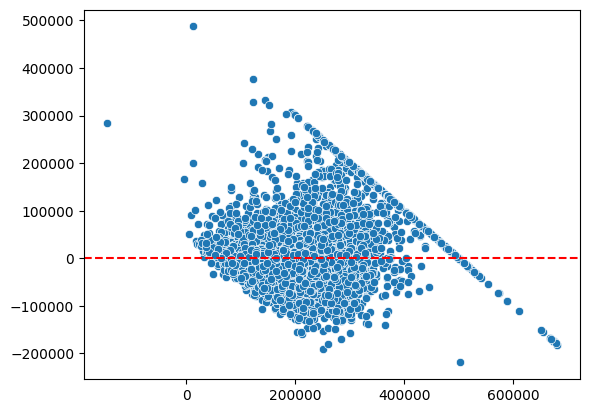

In [78]:
sns.scatterplot(
    # data = residual,
    x = y_predict,
    y =  residual,
    )
plt.axhline(y=0, color="red", linestyle="--")